# Visualizing the images used to compute the metrics

This notebook is **standalone**: it `git clone`s/`git pull`s the `galaxy-morphometrics` repo, then displays 10 postage stamps across 4 columns:

1. **Raw data** — the stamp as loaded from the Hugging Face dataset.
2. **Data with mask applied** — the same stamp after the processing applied when `--mask-field` is used: bad pixels (red contour) are replaced by the local estimate (`galmorph.stats._fill_masked`, local median) used internally for the CAS/Gini-M20/MID indicators.
3. **Raw reconstruction** — the autoencoder's output (`Autoencoder.reconstruct`), noise-free.
4. **Reconstruction + noise** — the same reconstruction after `galmorph.data.add_noise` (white noise scaled by the `noise_map`).

Display: no normalization by default (`imshow` picks `vmin`/`vmax` per panel). The `SHARED_ROW_SCALE` option (config cell) lets you force a common `vmin`/`vmax` per row (raw min/max of the initial stamp, no stretch or ZScale) if you want to compare levels across columns.

Dependencies: this notebook imports neither `galsim` nor `rpy2`/R (only used by `galmorph/stats.py` for HSM moments and the CAS/Gini-M20/MID indicators, never called here). If `AUTOENCODER_SPEC = "galmorph.autoencoder:WandBGalaxyAutoencoder"`, the PSF reconvolution (`self.model.convolve`, in the external `pshear` package) actually uses `jax_galsim` (a JAX reimplementation of GalSim, see `pshear/galaxy.py:convolve_galsim`) — not classic `galsim`. That's a transitive dependency of `pshear`, already listed as a comment in `requirements.txt` (`#jax_galsim`), to install if you use this autoencoder.

In [1]:
# --- Config: adapt before running ---

from google.colab import userdata
import os

REPO_URL = "https://github.com/VincentB03/galaxy-morphometrics.git"
REPO_DIR = "galaxy-morphometrics"  # local folder (created next to the notebook)
GIT_TOKEN = userdata.get('GIT_TOKEN')  # set a token if the repo is private, e.g. os.environ["GITHUB_TOKEN"]

# --- Hugging Face dataset ---
DATASET = "VincentB03/euclid-Q1-V2"       # <-- replace
HF_CONFIG = None
SPLIT = "train"
IMAGE_FIELD = "sci_subtracted"                   # <-- adapt to the dataset's column name
MASK_FIELD = "binary_mask"                     # mask column (1=valid/0=defective), or None to disable
PSF_FIELD = "psf_residual"                 # PSF column (needed by WandBGalaxyAutoencoder), or None
NOISE_MAP_FIELD = "noise_map"           # per-pixel noise std column, or None
N_SAMPLES = 10                          # exactly the 10 images to display
STAMP_SIZE = 64
NOISE_SEED = 0
HF_TOKEN = userdata.get('HF_TOKEN')                         # or os.environ.get("HF_TOKEN")

# --- Autoencoder (set to None to only display columns 1 and 2) ---
AUTOENCODER_SPEC = "galmorph.autoencoder:WandBGalaxyAutoencoder"
ENCODER_PATH = "vincentb03-imt-atlantique/Test-AE-partial-2/w99mkmar"  # WandB run_path
DECODER_PATH = "2000"                   # checkpoint epoch

# --- Display ---
# False (default): each panel gets its own vmin/vmax, chosen automatically
#                  by matplotlib from THAT panel's data (no normalization).
# True            : the 4 panels of a given row share the same vmin/vmax
#                  (raw min/max of the initial stamp), to compare levels
#                  across columns -- still no ZScale or stretch, just a
#                  linear min/max.
SHARED_ROW_SCALE = False

## 1. Fetching the repo (git clone / git pull)

In [2]:
import os
import subprocess
import sys

repo_url = REPO_URL
if GIT_TOKEN:
    repo_url = REPO_URL.replace("https://", "https://%s@" % GIT_TOKEN)

if os.path.isdir(os.path.join(REPO_DIR, ".git")):
    print("Repo already present, git pull...")
    subprocess.run(["git", "-C", REPO_DIR, "pull"], check=True)
else:
    print("Cloning repo...")
    subprocess.run(["git", "clone", repo_url, REPO_DIR], check=True)

repo_path = os.path.abspath(REPO_DIR)
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

Cloning repo...


## 2. Imports

In [3]:
%cd galaxy-morphometrics/
!pip install -r requirements.txt --quiet

/content/galaxy-morphometrics
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.2/314.2 kB 22.1 MB/s eta 0:00:00


In [4]:
import importlib

import numpy as np
import matplotlib.pyplot as plt

from galmorph.data import add_noise, load_hf_stamps
from galmorph.stats import _fill_masked


def build_autoencoder(spec, encoder_path, decoder_path):
    module_name, class_name = spec.split(":")
    cls = getattr(importlib.import_module(module_name), class_name)
    args = [a for a in (encoder_path, decoder_path) if a is not None]
    return cls(*args)

In [5]:
%cd ..

/content


In [6]:
REPO_URL = "https://github.com/VincentB03/Train-AE.git"
REPO_DIR = "Train-AE"  # local folder (created next to the notebook)

repo_url = REPO_URL
if GIT_TOKEN:
    repo_url = REPO_URL.replace("https://", "https://%s@" % GIT_TOKEN)

if os.path.isdir(os.path.join(REPO_DIR, ".git")):
    print("Repo already present, git pull...")
    subprocess.run(["git", "-C", REPO_DIR, "pull"], check=True)
else:
    print("Cloning repo...")
    subprocess.run(["git", "clone", repo_url, REPO_DIR], check=True)

repo_path = os.path.abspath(REPO_DIR)
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

Cloning repo...


In [7]:
%cd Train-AE/
!pip install -r requirements.txt --quiet
%cd ..

/content/Train-AE
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.3/27.3 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.4/187.4 kB 19.5 MB/s eta 0:00:00
/content


In [8]:
import sys
sys.path.append('/content/Train-AE')

## 3. Loading the 10 stamps (+ mask / PSF / noise map if configured)

In [9]:
loaded = load_hf_stamps(
    DATASET,
    split=SPLIT,
    image_field=IMAGE_FIELD,
    n_samples=N_SAMPLES,
    stamp_size=STAMP_SIZE,
    hf_config=HF_CONFIG,
    hf_token=HF_TOKEN,
    psf_field=PSF_FIELD,
    noise_map_field=NOISE_MAP_FIELD,
    mask_field=MASK_FIELD,
)

if PSF_FIELD or NOISE_MAP_FIELD or MASK_FIELD:
    real_images, extra = loaded
else:
    real_images, extra = loaded, {}

psf_images = extra.get("psf")
noise_map = extra.get("noise_map")
real_masks = extra.get("mask")  # convention: nonzero = bad pixel (already flipped by load_hf_stamps)

print("Loaded %d stamps of size %dx%d" % (len(real_images), STAMP_SIZE, STAMP_SIZE))

README.md:   0%|          | 0.00/3.24k [00:00<?, ?B/s]

data/train-00000-of-00006.parquet:   0%|          | 0.00/331M [00:00<?, ?B/s]

data/train-00001-of-00006.parquet:   0%|          | 0.00/331M [00:00<?, ?B/s]

data/train-00002-of-00006.parquet:   0%|          | 0.00/331M [00:00<?, ?B/s]

data/train-00003-of-00006.parquet:   0%|          | 0.00/331M [00:00<?, ?B/s]

data/train-00004-of-00006.parquet:   0%|          | 0.00/331M [00:00<?, ?B/s]

data/train-00005-of-00006.parquet:   0%|          | 0.00/331M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50362 [00:00<?, ? examples/s]

Loaded 10 stamps of size 64x64


## 4. Reconstruction (raw + with noise)

In [10]:
if AUTOENCODER_SPEC:
    ae = build_autoencoder(AUTOENCODER_SPEC, ENCODER_PATH, DECODER_PATH)
    recon_kwargs = {"psf": psf_images} if psf_images is not None else {}
    reconstruction = ae.reconstruct(real_images, **recon_kwargs)

    if noise_map is not None:
        reconstruction_noisy = add_noise(reconstruction, noise_map, seed=NOISE_SEED)
    else:
        print("NOISE_MAP_FIELD not configured -- column 4 is identical to column 3")
        reconstruction_noisy = reconstruction
else:
    print("AUTOENCODER_SPEC=None -- only columns 1 and 2 will be displayed")
    reconstruction = None
    reconstruction_noisy = None

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
/usr/local/lib/python3.12/dist-packages/jax_galsim/image.py:566: UserWarning: Explicitly requested dtype <class 'jax.numpy.complex128'> requested in zeros is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return jnp.zeros(shape=shape, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/jax/_src/numpy/scalar_types.py:50: UserWarning: Explicitly requested dtype float64 requested in asarray is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return asarray(x, dtype=self.dtype)


## 5. "Real" data as modified by the mask parameter

Reproduces exactly the processing done by `galmorph.stats.morph_stats`: pixels flagged as bad are replaced by the local median (`_fill_masked`) before computing the indicators, instead of being left at their raw value.

In [11]:
if real_masks is not None:
    masked_images = np.stack(
        [
            _fill_masked(real_images[i], real_masks[i] != 0) if (real_masks[i] != 0).any() else real_images[i]
            for i in range(len(real_images))
        ]
    )
else:
    print("MASK_FIELD not configured -- column 2 is identical to column 1")
    masked_images = real_images

## 6. 10-image x 4-column grid

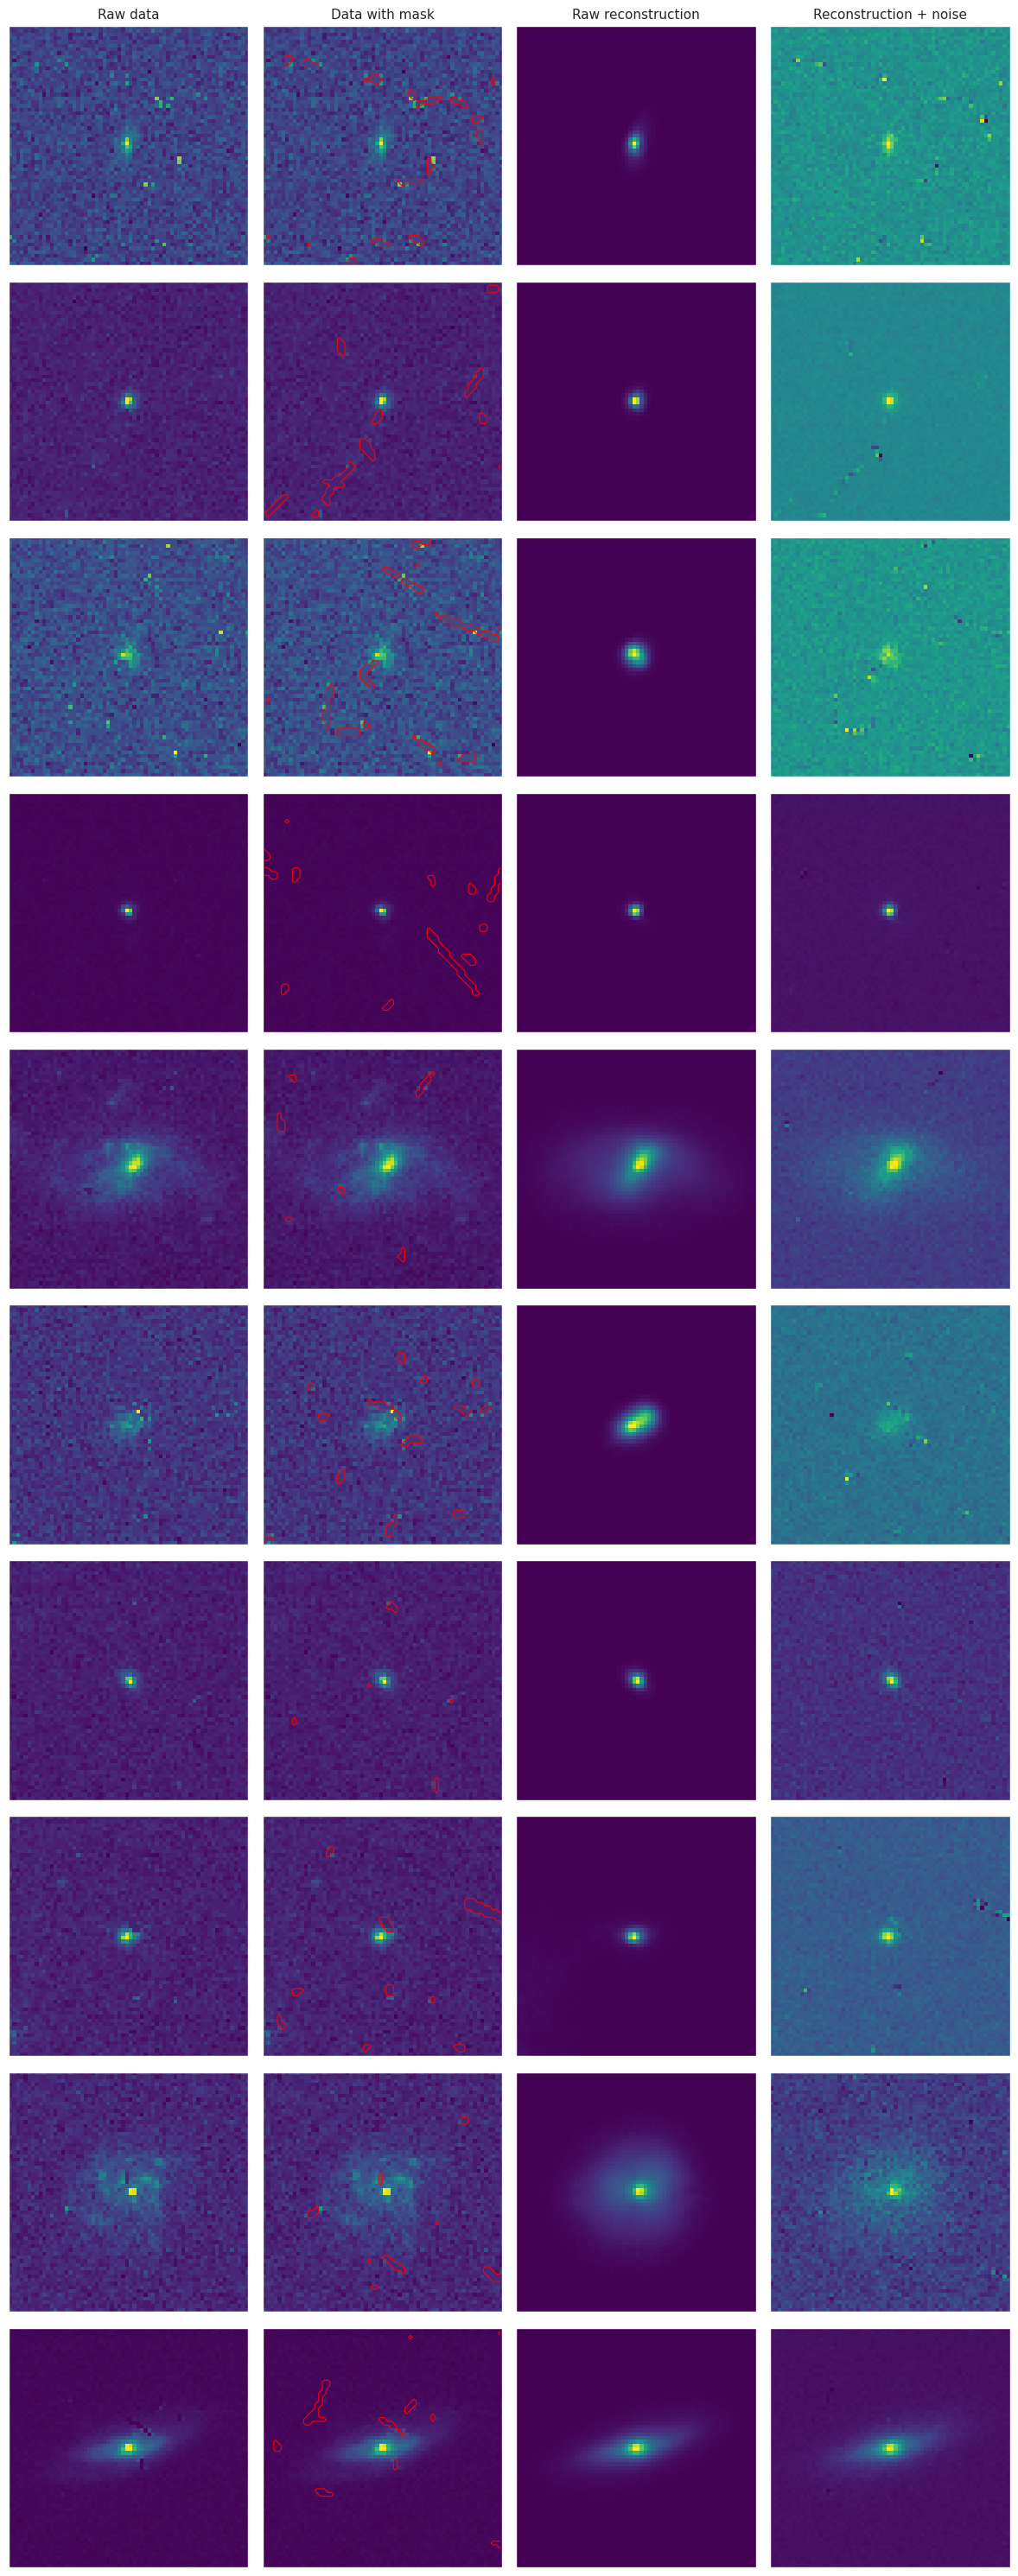

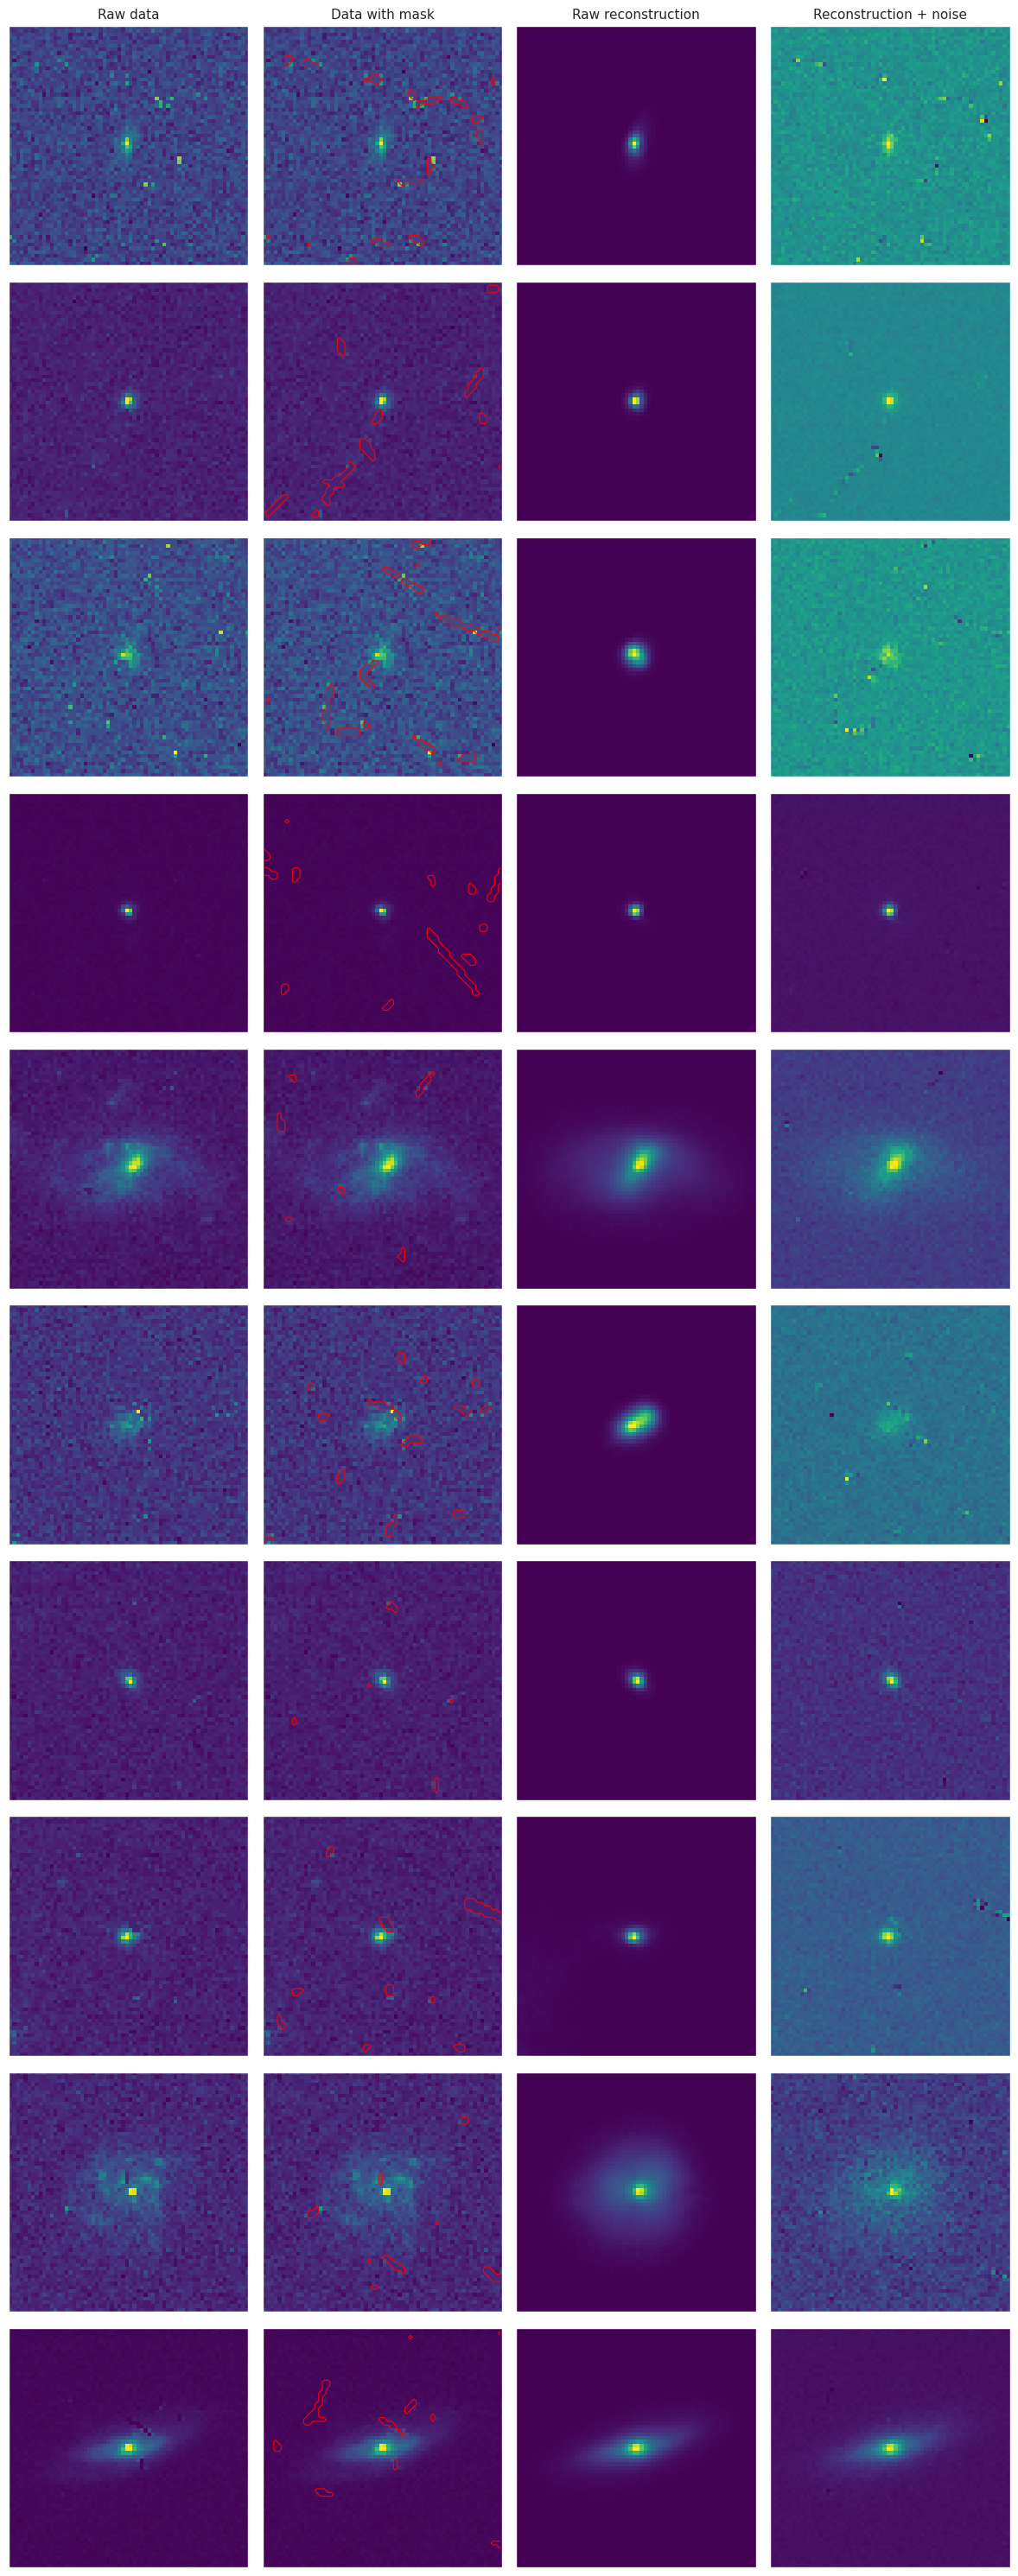

In [14]:
%matplotlib inline
import matplotlib.pyplot as plt
columns = [("Raw data", real_images), ("Data with mask", masked_images)]
if reconstruction is not None:
    columns.append(("Raw reconstruction", reconstruction))
    columns.append(("Reconstruction + noise", reconstruction_noisy))

n_rows = len(real_images)
n_cols = len(columns)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
if n_rows == 1:
    axes = axes[np.newaxis, :]
if n_cols == 1:
    axes = axes[:, np.newaxis]

for row in range(n_rows):
    if SHARED_ROW_SCALE:
        vmin, vmax = real_images[row].min(), real_images[row].max()
        imshow_kwargs = {"vmin": vmin, "vmax": vmax}
    else:
        imshow_kwargs = {}  # let imshow pick vmin/vmax per panel, no normalization

    for col, (title, stack) in enumerate(columns):
        ax = axes[row, col]
        ax.imshow(stack[row], origin="lower", cmap="viridis", **imshow_kwargs)
        ax.set_xticks([])
        ax.set_yticks([])
        if title == "Data with mask" and real_masks is not None:
            bad = real_masks[row] != 0
            if bad.any():
                ax.contour(bad, levels=[0.5], colors="red", linewidths=0.8)
        if row == 0:
            ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.show()

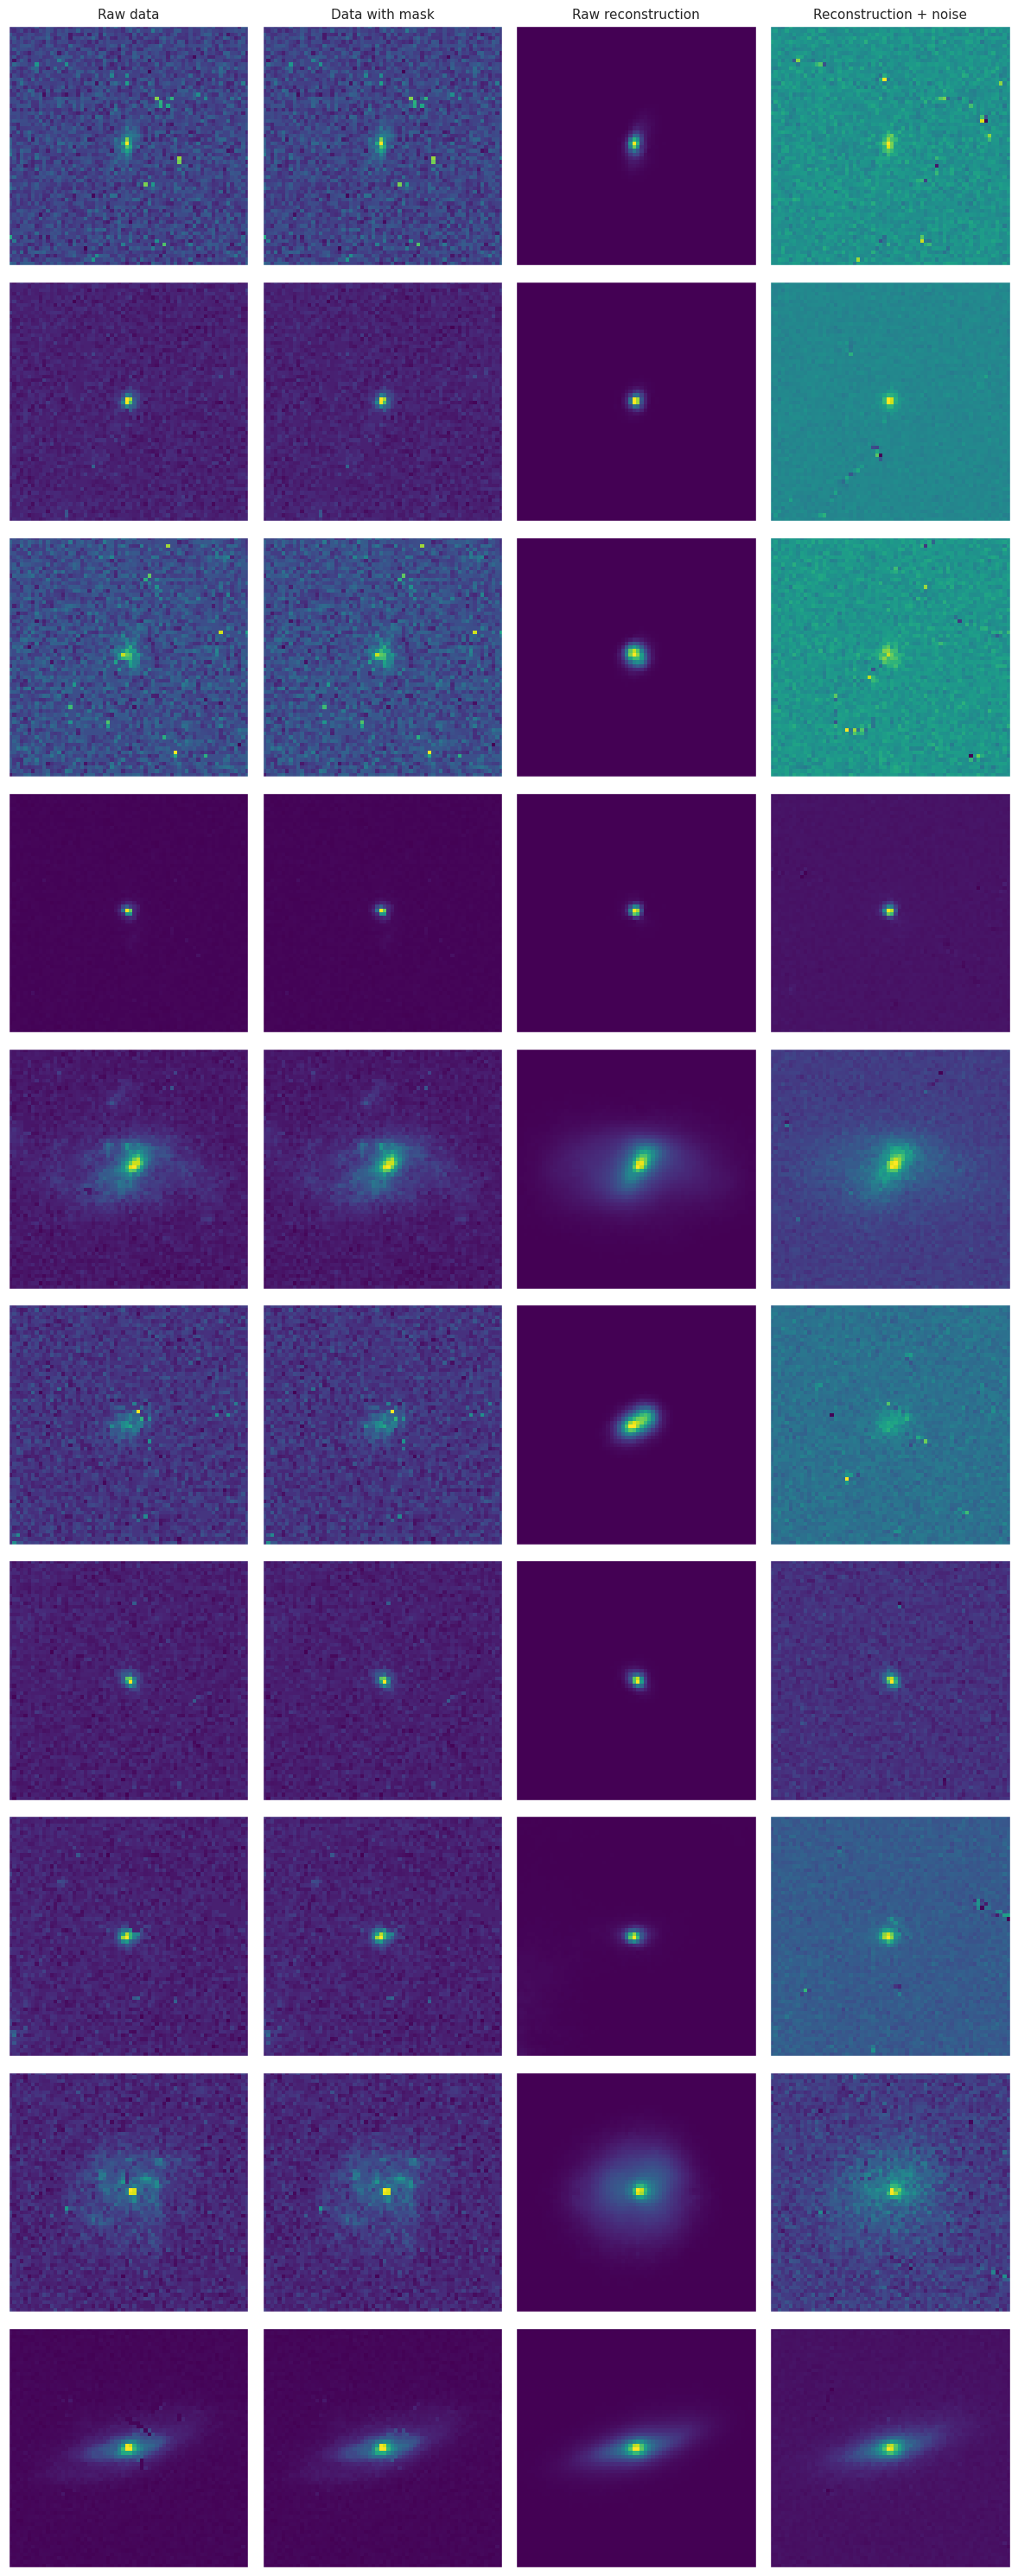

In [15]:
%matplotlib inline
import matplotlib.pyplot as plt
columns = [("Raw data", real_images), ("Data with mask", masked_images)]
if reconstruction is not None:
    columns.append(("Raw reconstruction", reconstruction))
    columns.append(("Reconstruction + noise", reconstruction_noisy))

n_rows = len(real_images)
n_cols = len(columns)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
if n_rows == 1:
    axes = axes[np.newaxis, :]
if n_cols == 1:
    axes = axes[:, np.newaxis]

for row in range(n_rows):
    if SHARED_ROW_SCALE:
        vmin, vmax = real_images[row].min(), real_images[row].max()
        imshow_kwargs = {"vmin": vmin, "vmax": vmax}
    else:
        imshow_kwargs = {}  # let imshow pick vmin/vmax per panel, no normalization

    for col, (title, stack) in enumerate(columns):
        ax = axes[row, col]
        ax.imshow(stack[row], origin="lower", cmap="viridis", **imshow_kwargs)
        ax.set_xticks([])
        ax.set_yticks([])
        if title == "Data with mask" and real_masks is not None:
            bad = real_masks[row] != 0
        if row == 0:
            ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.show()